# Bloch gauge benchmark for the gauge-fixed patcher

This notebook tests four things:

1. The new patcher can impose a smooth parallel-transport gauge along the FS contour.
2. The `interaction.py` interface is still compatible with the new patchset.
3. A raw projected vertex is **gauge-covariant**, not entrywise gauge-invariant.
4. Gauge-invariant diagnostics such as `|Γ|` and singular values of channel kernels stay unchanged under arbitrary patchwise rephasing.

Run all cells from top to bottom.


In [16]:
import noninteracting
import interaction
import channels
import patching_gaugefixed as patching_new
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Build two patch sets for the same FS:
#   - raw eigenvectors from the eigensolver
#   - parallel-transport gauge fixed eigenvectors

model = noninteracting.KagomeNagaosa({"t": 1.0, "phi": 0.0}, spin=False)
mu = model.EF_from_filling(5/12, N=160)

patcher_raw = patching_new.FSPatcher(
    model,
    band_index=1,
    mu=mu,
    grid_size=180,
    Npatch=36,
    gauge_fix=None,
)

patcher_fix = patching_new.FSPatcher(
    model,
    band_index=1,
    mu=mu,
    grid_size=180,
    Npatch=36,
    gauge_fix="parallel_transport",
    close_loop_gauge=True,
)

PS_raw = patcher_raw.build()
PS_fix = patcher_fix.build()

print("mu =", mu)
print("raw gauge_method =", PS_raw.gauge_method)
print("fix gauge_method =", PS_fix.gauge_method)
print("fix gauge_loop_phase =", PS_fix.gauge_loop_phase)


mu = -8.385989035802826e-17
raw gauge_method = None
fix gauge_method = parallel_transport
fix gauge_loop_phase = -4.964379191473945e-32


In [5]:
def nearest_neighbor_overlap_stats(PS):
    U = np.array([p.eigvec for p in PS.patches])
    ovs = np.array([np.vdot(U[i], U[(i+1) % PS.Npatch]) for i in range(PS.Npatch)])
    phase_abs = np.abs(np.angle(ovs))
    return {
        "mean_abs_phase_jump": float(np.mean(phase_abs)),
        "max_abs_phase_jump": float(np.max(phase_abs)),
        "min_abs_overlap": float(np.min(np.abs(ovs))),
        "mean_abs_overlap": float(np.mean(np.abs(ovs))),
        "all_overlaps": ovs,
    }

stats_raw = nearest_neighbor_overlap_stats(PS_raw)
stats_fix = nearest_neighbor_overlap_stats(PS_fix)

print("RAW  mean |phase jump| =", stats_raw["mean_abs_phase_jump"])
print("RAW  max  |phase jump| =", stats_raw["max_abs_phase_jump"])
print("FIX  mean |phase jump| =", stats_fix["mean_abs_phase_jump"])
print("FIX  max  |phase jump| =", stats_fix["max_abs_phase_jump"])
print("FIX  min  |overlap|    =", stats_fix["min_abs_overlap"])


RAW  mean |phase jump| = 0.8726646259971648
RAW  max  |phase jump| = 3.141592653589793
FIX  mean |phase jump| = 1.3912494064695006e-32
FIX  max  |phase jump| = 4.99536871643217e-32
FIX  min  |overlap|    = 0.9597713190177934


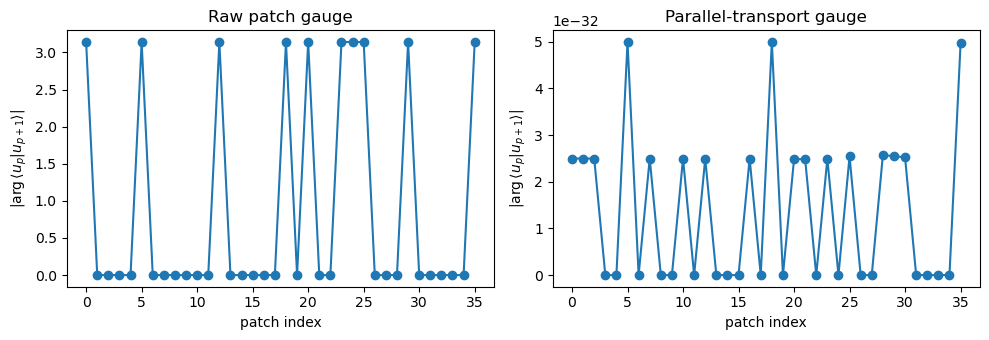

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(np.abs(np.angle(stats_raw["all_overlaps"])), marker="o")
axes[0].set_title("Raw patch gauge")
axes[0].set_xlabel("patch index")
axes[0].set_ylabel(r"$|\arg\langle u_p|u_{p+1}\rangle|$")

axes[1].plot(np.abs(np.angle(stats_fix["all_overlaps"])), marker="o")
axes[1].set_title("Parallel-transport gauge")
axes[1].set_xlabel("patch index")
axes[1].set_ylabel(r"$|\arg\langle u_p|u_{p+1}\rangle|$")

plt.tight_layout()
plt.show()


In [7]:
# Compatibility with interaction.py
bare = interaction.BareExtendedHubbard.from_kagome_model(model, U=2.0, V=1.0)

g0 = bare.patch_vertex({"up": PS_fix, "dn": PS_fix}, 0, "up", 1, "dn", 2, "up", 3, "dn", antisym=False)
G0 = bare.patch_vertex({"up": PS_fix, "dn": PS_fix}, 0, "up", 1, "dn", 2, "up", 3, "dn", antisym=True)

print("direct patch vertex =", g0)
print("antisym patch vertex =", G0)
print("interaction interface OK")


direct patch vertex = (1.7976879980391953+2.801024362868186e-32j)
antisym patch vertex = (1.7976879980391953+2.801024362868186e-32j)
interaction interface OK


In [12]:
def random_rephase_patchset(PS, rng):
    phases = np.exp(1j * rng.uniform(0.0, 2*np.pi, size=PS.Npatch))
    U = np.array([p.eigvec for p in PS.patches], dtype=complex)
    U2 = phases[:, None] * U
    return PS.copy_with_eigvecs(U2, gauge_method="manual_random_rephase"), phases
rng = np.random.default_rng(12345)
PS_rand, phases = random_rephase_patchset(PS_fix, rng)

# Compare one direct and one antisym vertex before/after rephasing.
p1, p2, p3, p4 = 0, 1, 2, 3

g_before = bare.patch_vertex({"up": PS_fix, "dn": PS_fix}, p1, "up", p2, "dn", p3, "up", p4, "dn", antisym=False)
g_after  = bare.patch_vertex({"up": PS_rand, "dn": PS_rand}, p1, "up", p2, "dn", p3, "up", p4, "dn", antisym=False)

G_before = bare.patch_vertex({"up": PS_fix, "dn": PS_fix}, p1, "up", p2, "dn", p3, "up", p4, "dn", antisym=True)
G_after  = bare.patch_vertex({"up": PS_rand, "dn": PS_rand}, p1, "up", p2, "dn", p3, "up", p4, "dn", antisym=True)

pred_phase = np.conjugate(phases[p3]) * np.conjugate(phases[p4]) * phases[p2] * phases[p1]

print("direct vertex raw difference       =", abs(g_after - g_before))
print("direct vertex covariance residual  =", abs(g_after - pred_phase * g_before))
print("antisym vertex raw difference      =", abs(G_after - G_before))
print("antisym vertex covariance residual =", abs(G_after - pred_phase * G_before))
print("|direct| invariant residual        =", abs(abs(g_after) - abs(g_before)))
print("|antisym| invariant residual       =", abs(abs(G_after) - abs(G_before)))


direct vertex raw difference       = 0.7895336700046102
direct vertex covariance residual  = 0.0
antisym vertex raw difference      = 0.7895336700046102
antisym vertex covariance residual = 0.0
|direct| invariant residual        = 2.220446049250313e-16
|antisym| invariant residual       = 2.220446049250313e-16


In [13]:
# Gauge-invariant channel diagnostics:
# under independent patchwise rephasings on row/column spaces,
# singular values should stay unchanged.

dec_fix = channels.ChannelDecomposer(bare, {"up": PS_fix, "dn": PS_fix})
dec_rand = channels.ChannelDecomposer(bare, {"up": PS_rand, "dn": PS_rand})

Q = np.zeros(2)
K_fix = dec_fix.pp_kernel(Q, incoming_spins=("up", "dn"), outgoing_spins=("up", "dn"))
K_rand = dec_rand.pp_kernel(Q, incoming_spins=("up", "dn"), outgoing_spins=("up", "dn"))

s_fix = np.linalg.svd(K_fix.matrix, compute_uv=False)
s_rand = np.linalg.svd(K_rand.matrix, compute_uv=False)

print("pp kernel entrywise difference =", np.max(np.abs(K_rand.matrix - K_fix.matrix)))
print("pp kernel singular-value diff  =", np.max(np.abs(np.sort(s_rand) - np.sort(s_fix))))
print("pp kernel hermitian residual (fix)  =", K_fix.hermitian_residual())
print("pp kernel hermitian residual (rand) =", K_rand.hermitian_residual())


pp kernel entrywise difference = 3.978851297641735
pp kernel singular-value diff  = 1.4210854715202004e-14
pp kernel hermitian residual (fix)  = 4.440892098500626e-16
pp kernel hermitian residual (rand) = 6.753223014464258e-16


In [14]:
# Optional: inspect the transformed-kernel relation explicitly.
# For pp with incoming/outgoing spins both ('up','dn') using the same patchset,
# the rephasing acts by a left/right diagonal unitary transformation.

D = np.diag(np.conjugate(phases[K_fix.row_patches]) * np.conjugate(phases[K_fix.row_partner_patches]))
C = np.diag(phases[K_fix.col_partner_patches] * phases[K_fix.col_patches])

cov_resid = np.max(np.abs(K_rand.matrix - D @ K_fix.matrix @ C))
print("pp kernel covariance residual =", cov_resid)


pp kernel covariance residual = 1.9984026207595845e-15


In [15]:
# Final summary
tests = []

def record(name, value, thresh, relation="<"):
    if relation == "<":
        ok = bool(value < thresh)
        text = f"{value:.3e} < {thresh:.3e}"
    else:
        ok = bool(value > thresh)
        text = f"{value:.3e} > {thresh:.3e}"
    tests.append((name, ok, text))

record("Gauge smoothing reduces mean phase jump",
       stats_fix["mean_abs_phase_jump"] / max(stats_raw["mean_abs_phase_jump"], 1e-30),
       1e-6, "<")

record("Gauge smoothing reduces max phase jump",
       stats_fix["max_abs_phase_jump"] / max(stats_raw["max_abs_phase_jump"], 1e-30),
       1e-6, "<")

record("Direct vertex is not entrywise gauge invariant",
       abs(g_after - g_before),
       1e-6, ">")

record("Direct vertex obeys gauge covariance",
       abs(g_after - pred_phase * g_before),
       1e-10, "<")

record("Antisym vertex obeys gauge covariance",
       abs(G_after - pred_phase * G_before),
       1e-10, "<")

record("|Gamma| is gauge invariant",
       abs(abs(G_after) - abs(G_before)),
       1e-10, "<")

record("Interaction/channels compatibility: pp singular values unchanged",
       np.max(np.abs(np.sort(s_rand) - np.sort(s_fix))),
       1e-10, "<")

record("Kernel-level covariance relation holds",
       cov_resid,
       1e-10, "<")

print("="*72)
print("Gauge benchmark summary")
print("="*72)
npass = 0
for name, ok, text in tests:
    flag = "PASS" if ok else "FAIL"
    npass += int(ok)
    print(f"[{flag}] {name}: {text}")
print("-"*72)
print(f"Total tests: {len(tests)}")
print(f"PASS: {npass}")
print(f"FAIL: {len(tests)-npass}")


Gauge benchmark summary
[PASS] Gauge smoothing reduces mean phase jump: 1.594e-32 < 1.000e-06
[PASS] Gauge smoothing reduces max phase jump: 1.590e-32 < 1.000e-06
[PASS] Direct vertex is not entrywise gauge invariant: 7.895e-01 > 1.000e-06
[PASS] Direct vertex obeys gauge covariance: 0.000e+00 < 1.000e-10
[PASS] Antisym vertex obeys gauge covariance: 0.000e+00 < 1.000e-10
[PASS] |Gamma| is gauge invariant: 2.220e-16 < 1.000e-10
[PASS] Interaction/channels compatibility: pp singular values unchanged: 1.421e-14 < 1.000e-10
[PASS] Kernel-level covariance relation holds: 1.998e-15 < 1.000e-10
------------------------------------------------------------------------
Total tests: 8
PASS: 8
FAIL: 0
